Configuration

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

FOLDER_PATH = os.getenv("FOLDER_PATH")
files = [f"{FOLDER_PATH}_{i:02d}" for i in range(1, 51)]
OUTPUT_PATH = os.getenv("OUTPUT_PATH")

def jis_to_unicode(jis_code):
    # JIS X 0208
    b1 = (jis_code >> 8) & 0xFF
    b2 = jis_code & 0xFF

    byte_seq = bytes([0x1B, 0x24, 0x42, b1, b2, 0x1B, 0x28, 0x42])

    return byte_seq.decode('iso2022_jp')

def unicode_to_jis(char):
    # JIS X 0208
    byte_seq = char.encode('iso2022_jp')
    if len(byte_seq) < 6:
        raise ValueError("Character cannot be converted to JIS code")

    b1 = byte_seq[3]
    b2 = byte_seq[4]

    jis_code = (b1 << 8) | b2
    return jis_code


hiragana = [
    'あ', 'い', 'う', 'え', 'お',
    'か', 'き', 'く', 'け', 'こ',
    'さ', 'し', 'す', 'せ', 'そ',
    'た', 'ち', 'つ', 'て', 'と',
    'な', 'に', 'ぬ', 'ね', 'の',
    'は', 'ひ', 'ふ', 'へ', 'ほ',
    'ま', 'み', 'む', 'め', 'も',
    'や', 'ゆ', 'よ',
    'ら', 'り', 'る', 'れ', 'ろ',
    'わ', 'を', 'ん'
]

kanji = [
    # First Grade (80 kanji)
    '一', '二', '三', '四', '五',
    '六', '七', '八', '九', '十',
    '百', '千', '上', '下', '左',
    '右', '中', '大', '小', '月',
    '日', '年', '早', '木', '林',
    '山', '川', '土', '空', '田',
    '天', '生', '花', '草', '虫',
    '犬', '人', '名', '女', '男',
    '子', '目', '耳', '口', '手',
    '足', '見', '音', '力', '気',
    '円', '入', '出', '立', '休',
    '先', '夕', '本', '文', '字',
    '学', '校', '村', '町', '森',
    '正', '水', '火', '玉', '王',
    '石', '竹', '糸', '貝', '車',
    '金', '雨', '赤', '青', '白',
    # Second Grade (160 kanji)
    '数', '多', '少', '万', '半',
    '形', '太', '細', '広', '長',
    '点', '丸', '交', '光', '角',
    '計', '直', '線', '矢', '弱',
    '父', '強', '高', '同', '親',
    '母', '姉', '兄', '弟', '妹',
    '自', '友', '体', '毛', '頭',
    '顔', '首', '心', '時', '曜',
    '朝', '昼', '夜', '分', '週',
    '春', '夏', '秋', '冬', '今',
    '新', '古', '間', '方', '北',
    '南', '東', '西', '遠', '近',
    '前', '後', '内', '外', '場',
    '地', '国', '園', '谷', '野',
    '原', '里', '市', '京', '風',
    '雪', '雲', '池', '海', '岩',
    '星', '室', '戸', '家', '寺',
    '通', '門', '道', '話', '言',
    '答', '声', '聞', '語', '読',
    '書', '記', '紙', '画', '絵',
    '図', '工', '教', '晴', '思',
    '考', '知', '才', '理', '算',
    '作', '元', '食', '肉', '馬',
    '牛', '魚', '鳥', '羽', '鳴',
    '麦', '米', '茶', '色', '黄',
    '黒', '来', '行', '帰', '歩',
    '走', '止', '活', '店', '買',
    '売', '午', '汽', '弓', '回',
    '会', '組', '船', '明', '社',
    '切', '電', '毎', '合', '当',
    '台', '楽', '公', '引', '科',
    '歌', '刀', '番', '用', '何',
    # Third Grade (200 kanji)
    '丁', '世', '両', '主', '乗',
    '予', '事', '仕', '他', '代',
    '住', '使', '係', '倍', '全',
    '具', '写', '列', '助', '勉',
    '動', '勝', '化', '区', '医',
    '去', '反', '取', '受', '号',
    '向', '君', '味', '命', '和',
    '品', '員', '商', '問', '坂',
    '央', '始', '委', '守', '安',
    '定', '実', '客', '宮', '宿',
    '寒', '対', '局', '屋', '岸',
    '島', '州', '帳', '平', '幸',
    '度', '庫', '庭', '式', '役',
    '待', '急', '息', '悪', '悲',
    '想', '意', '感', '所', '打',
    '投', '拾', '持', '指', '放',
    '整', '旅', '族', '昔', '昭',
    '暑', '暗', '曲', '有', '服',
    '期', '板', '柱', '根', '植',
    '業', '様', '横', '橋', '次',
    '歯', '死', '氷', '決', '油',
    '波', '注', '泳', '洋', '流',
    '消', '深', '温', '港', '湖',
    '湯', '漢', '炭', '物', '球',
    '由', '申', '界', '畑', '病',
    '発', '登', '皮', '皿', '相',
    '県', '真', '着', '短', '研',
    '礼', '神', '祭', '福', '秒',
    '究', '章', '童', '笛', '第',
    '筆', '等', '箱', '級', '終',
    '緑', '練', '羊', '美', '習',
    '者', '育', '苦', '荷', '落',
    '葉', '薬', '血', '表', '詩',
    '調', '談', '豆', '負', '起',
    '路', '身', '転', '軽', '農',
    '返', '追', '送', '速', '進',
    '遊', '運', '部', '都', '配',
    '酒', '重', '鉄', '銀', '開',
    '院', '陽', '階', '集', '面',
    '題', '飲', '館', '駅', '鼻',
    # Fourth Grade (200 kanji)
    '不', '争', '付', '令', '以',
    '仲', '伝', '位', '低', '例',
    '便', '信', '倉', '候', '借',
    '停', '健', '側', '働', '億',
    '兆', '児', '共', '兵', '典',
    '冷', '初', '別', '利', '刷',
    '副', '功', '加', '努', '労',
    '勇', '包', '卒', '協', '単',
    '博', '印', '参', '史', '司',
    '各', '告', '周', '唱', '喜',
    '器', '囲', '固', '型', '堂',
    '塩', '士', '変', '夫', '失',
    '好', '季', '孫', '完', '官',
    '害', '察', '巣', '差', '希',
    '席', '帯', '底', '府', '康',
    '建', '径', '徒', '得', '必',
    '念', '愛', '成', '戦', '折',
    '挙', '改', '救', '敗', '散',
    '料', '旗', '昨', '景', '最',
    '望', '未', '末', '札', '材',
    '束', '松', '果', '栄', '案',
    '梅', '械', '極', '標', '機',
    '欠', '歴', '残', '殺', '毒',
    '氏', '民', '求', '治', '法',
    '泣', '浅', '浴', '清', '満',
    '漁', '灯', '無', '然', '焼',
    '照', '熱', '牧', '特', '産',
    '的', '省', '祝', '票', '種',
    '積', '競', '笑', '管', '節',
    '粉', '紀', '約', '結', '給',
    '続', '置', '老', '胃', '脈',
    '腸', '臣', '航', '良', '芸',
    '芽', '英', '菜', '街', '衣',
    '要', '覚', '観', '訓', '試',
    '説', '課', '議', '象', '貨',
    '貯', '費', '賞', '軍', '輪',
    '辞', '辺', '連', '達', '選',
    '郡', '量', '録', '鏡', '関',
    '陸', '隊', '静', '順', '願',
    '類', '飛', '飯', '養', '験',
    # Fifth Grade (185 kanji)
    '久', '仏', '仮', '件', '任',
    '似', '余', '価', '保', '修',
    '俵', '個', '備', '像', '再',
    '刊', '判', '制', '券', '則',
    '効', '務', '勢', '厚', '句',
    '可', '営', '因', '団', '圧',
    '在', '均', '基', '報', '境',
    '墓', '増', '夢', '妻', '婦',
    '容', '寄', '富', '導', '居',
    '属', '布', '師', '常', '幹',
    '序', '弁', '張', '往', '復',
    '徳', '志', '応', '快', '性',
    '恩', '情', '態', '慣', '承',
    '技', '招', '授', '採', '接',
    '提', '損', '支', '政', '故',
    '敵', '断', '旧', '易', '暴',
    '条', '枝', '査', '格', '桜',
    '検', '構', '武', '比', '永',
    '河', '液', '混', '減', '測',
    '準', '演', '潔', '災', '燃',
    '版', '犯', '状', '独', '率',
    '現', '留', '略', '益', '眼',
    '破', '確', '示', '祖', '禁',
    '移', '程', '税', '築', '精',
    '素', '経', '統', '絶', '綿',
    '総', '編', '績', '織', '罪',
    '群', '義', '耕', '職', '肥',
    '能', '興', '舌', '舎', '術',
    '衛', '製', '複', '規', '解',
    '設', '許', '証', '評', '講',
    '謝', '識', '護', '豊', '財',
    '貧', '責', '貸', '貿', '賀',
    '資', '賛', '質', '輸', '述',
    '迷', '退', '逆', '造', '過',
    '適', '酸', '鉱', '銅', '銭',
    '防', '限', '険', '際', '雑',
    '非', '預', '領', '額', '飼',
    # Sixth Grade (181)
    '並', '乱', '乳', '亡', '仁',
    '供', '俳', '値', '傷', '優',
    '党', '冊', '処', '刻', '割',
    '創', '劇', '勤', '危', '卵',
    '厳', '収', '后', '否', '吸',
    '呼', '善', '困', '垂', '城',
    '域', '奏', '奮', '姿', '存',
    '孝', '宅', '宇', '宗', '宙',
    '宝', '宣', '密', '寸', '専',
    '射', '将', '尊', '就', '尺',
    '届', '展', '層', '己', '巻',
    '幕', '干', '幼', '庁', '座',
    '延', '律', '従', '忘', '忠',
    '憲', '我', '批', '担', '拝',
    '拡', '捨', '探', '推', '揮',
    '操', '敬', '映', '晩', '暖',
    '暮', '朗', '机', '枚', '染',
    '株', '棒', '模', '権', '樹',
    '欲', '段', '沿', '泉', '洗',
    '派', '済', '源', '潮', '激',
    '灰', '熟', '片', '班', '異',
    '疑', '痛', '皇', '盛', '盟',
    '看', '砂', '磁', '私', '秘',
    '穀', '穴', '窓', '筋', '策',
    '簡', '糖', '系', '紅', '納',
    '純', '絹', '縦', '縮', '署',
    '翌', '聖', '肺', '背', '胸',
    '脳', '腹', '臓', '臨', '至',
    '若', '著', '蒸', '蔵', '蚕',
    '衆', '裁', '装', '裏', '補',
    '視', '覧', '討', '訪', '訳',
    '詞', '誌', '認', '誕', '誠',
    '誤', '論', '諸', '警', '貴',
    '賃', '遺', '郵', '郷', '針',
    '鋼', '閉', '閣', '降', '陛',
    '除', '障', '難', '革', '頂',
    '骨'
    # Junior High School part 1 (316 kanji)
    '握', '扱', '依', '威', '為',
    '偉', '違', '維', '緯', '壱',
    '芋', '陰', '隠', '影', '鋭',
    '越', '援', '煙', '鉛', '縁',
    '汚', '押', '奥', '憶', '菓',
    '暇', '箇', '雅', '介', '戒',
    '皆', '壊', '較', '獲', '刈',
    '甘', '汗', '乾', '勧', '歓',
    '監', '環', '鑑', '含', '奇',
    '祈', '鬼', '幾', '輝', '儀',
    '戯', '詰', '却', '脚', '及',
    '丘', '朽', '巨', '拠', '距',
    '御', '凶', '叫', '狂', '況',
    '狭', '恐', '響', '驚', '仰',
    '駆', '屈', '掘', '繰', '恵',
    '傾', '継', '迎', '撃', '肩',
    '兼', '剣', '軒', '圏', '堅',
    '遣', '玄', '枯', '誇', '鼓',
    '互', '抗', '攻', '更', '恒',
    '荒', '香', '項', '稿', '豪',
    '込', '婚', '鎖', '彩', '歳',
    '載', '剤', '咲', '惨', '旨',
    '伺', '刺', '脂', '紫', '雌',
    '執', '芝', '斜', '煮', '釈',
    '寂', '朱', '狩', '趣', '需',
    '舟', '秀', '襲', '柔', '獣',
    '瞬', '旬', '巡', '盾', '召',
    '床', '沼', '称', '紹', '詳',
    '丈', '畳', '殖', '飾', '触',
    '侵', '振', '浸', '寝', '慎',
    '震', '薪', '尽', '陣', '尋',
    '吹', '是', '井', '姓', '征',
    '跡', '占', '扇', '鮮', '訴',
    '僧', '燥', '騒', '贈', '即',
    '俗', '耐', '替', '沢', '拓',
    '濁', '脱', '丹', '淡', '嘆',
    '端', '弾', '恥', '致', '遅',
    '蓄', '沖', '跳', '徴', '澄',
    '沈', '珍', '抵', '堤', '摘',
    '滴', '添', '殿', '吐', '途',
    '渡', '奴', '怒', '到', '逃',
    '倒', '唐', '桃', '透', '盗',
    '塔', '稲', '踏', '闘', '胴',
    '峠', '突', '鈍', '曇', '弐',
    '悩', '濃', '杯', '輩', '拍',
    '泊', '迫', '薄', '爆', '髪',
    '抜', '罰', '般', '販', '搬',
    '範', '繁', '盤', '彼', '疲',
    '被', '避', '尾', '微', '匹',
    '描', '浜', '敏', '怖', '浮',
    '普', '腐', '敷', '膚', '賦',
    '舞', '幅', '払', '噴', '柄',
    '壁', '捕', '舗', '抱', '峰',
    '砲', '忙', '坊', '肪', '冒',
    '傍', '帽', '凡', '盆', '慢',
    '漫', '妙', '眠', '矛', '霧',
    '娘', '茂', '猛', '網', '黙',
    '紋', '躍', '雄', '与', '誉',
    '溶', '腰', '踊', '謡', '翼',
    '雷', '頼', '絡', '欄', '離',
    '粒', '慮', '療', '隣', '涙',
    '隷', '齢', '麗', '暦', '劣',
    '烈', '恋', '露', '郎', '惑',
    '腕',
    # Junior High School part 2 (285 kanji)
    '哀', '慰', '詠', '悦', '閲',
    '炎', '宴', '欧', '殴', '乙',
    '卸', '穏', '佳', '架', '華',
    '嫁', '餓', '怪', '悔', '塊',
    '慨', '該', '概', '郭', '隔',
    '穫', '岳', '掛', '滑', '肝',
    '冠', '勘', '貫', '喚', '換',
    '敢', '緩', '企', '岐', '忌',
    '軌', '既', '棋', '棄', '騎',
    '欺', '犠', '菊', '吉', '喫',
    '虐', '虚', '峡', '脅', '凝',
    '斤', '緊', '愚', '偶', '遇',
    '刑', '契', '啓', '掲', '携',
    '憩', '鶏', '鯨', '倹', '賢',
    '幻', '孤', '弧', '雇', '顧',
    '娯', '悟', '孔', '巧', '甲',
    '坑', '拘', '郊', '控', '慌',
    '硬', '絞', '綱', '酵', '克',
    '獄', '恨', '紺', '魂', '墾',
    '債', '催', '削', '搾', '錯',
    '撮', '擦', '暫', '祉', '施',
    '諮', '侍', '慈', '軸', '疾',
    '湿', '赦', '邪', '殊', '寿',
    '潤', '遵', '如', '徐', '匠',
    '昇', '掌', '晶', '焦', '衝',
    '鐘', '冗', '嬢', '錠', '譲',
    '嘱', '辱', '伸', '辛', '審',
    '炊', '粋', '衰', '酔', '遂',
    '穂', '随', '髄', '瀬', '牲',
    '婿', '請', '斥', '隻', '惜',
    '籍', '摂', '潜', '繕', '阻',
    '措', '粗', '礎', '双', '桑',
    '掃', '葬', '遭', '憎', '促',
    '賊', '怠', '胎', '袋', '逮',
    '滞', '滝', '択', '卓', '託',
    '諾', '奪', '胆', '鍛', '壇',
    '稚', '畜', '窒', '抽', '鋳',
    '駐', '彫', '超', '聴', '陳',
    '鎮', '墜', '帝', '訂', '締',
    '哲', '斗', '塗', '凍', '陶',
    '痘', '匿', '篤', '豚', '尿',
    '粘', '婆', '排', '陪', '縛',
    '伐', '帆', '伴', '畔', '藩',
    '蛮', '卑', '碑', '泌', '姫',
    '漂', '苗', '赴', '符', '封',
    '伏', '覆', '紛', '墳', '癖',
    '募', '慕', '簿', '芳', '邦',
    '奉', '胞', '倣', '崩', '飽',
    '縫', '乏', '妨', '房', '某',
    '膨', '謀', '墨', '没', '翻',
    '魔', '埋', '膜', '又', '魅',
    '滅', '免', '幽', '誘', '憂',
    '揚', '揺', '擁', '抑', '裸',
    '濫', '吏', '隆', '了', '猟',
    '陵', '糧', '厘', '励', '零',
    '霊', '裂', '廉', '錬', '炉',
    '浪', '廊', '楼', '漏', '湾',
    # Senior High School part 1 (333 kanji)
    '亜', '尉', '逸', '姻', '韻',
    '畝', '浦', '疫', '謁', '猿',
    '凹', '翁', '虞', '渦', '禍',
    '靴', '寡', '稼', '蚊', '拐',
    '懐', '劾', '涯', '垣', '核',
    '殻', '嚇', '潟', '括', '喝',
    '渇', '褐', '轄', '且', '缶',
    '陥', '患', '堪', '棺', '款',
    '閑', '寛', '憾', '還', '艦',
    '頑', '飢', '宜', '偽', '擬',
    '糾', '窮', '拒', '享', '挟',
    '恭', '矯', '暁', '菌', '琴',
    '謹', '襟', '吟', '隅', '勲',
    '薫', '茎', '渓', '蛍', '慶',
    '傑', '嫌', '献', '謙', '繭',
    '顕', '懸', '弦', '呉', '碁',
    '江', '肯', '侯', '洪', '貢',
    '溝', '衡', '購', '拷', '剛',
    '酷', '昆', '懇', '佐', '唆',
    '詐', '砕', '宰', '栽', '斎',
    '崎', '索', '酢', '桟', '傘',
    '肢', '嗣', '賜', '滋', '璽',
    '漆', '遮', '蛇', '酌', '爵',
    '珠', '儒', '囚', '臭', '愁',
    '酬', '醜', '汁', '充', '渋',
    '銃', '叔', '淑', '粛', '塾',
    '俊', '准', '殉', '循', '庶',
    '緒', '叙', '升', '抄', '肖',
    '尚', '宵', '症', '祥', '渉',
    '訟', '硝', '粧', '詔', '奨',
    '彰', '償', '礁', '浄', '剰',
    '縄', '壌', '醸', '津', '唇',
    '娠', '紳', '診', '刃', '迅',
    '甚', '帥', '睡', '枢', '崇',
    '据', '杉', '斉', '逝', '誓',
    '析', '拙', '窃', '仙', '栓',
    '旋', '践', '遷', '薦', '繊',
    '禅', '漸', '租', '疎', '塑',
    '壮', '荘', '捜', '挿', '曹',
    '喪', '槽', '霜', '藻', '妥',
    '堕', '惰', '駄', '泰', '濯',
    '但', '棚', '痴', '逐', '秩',
    '嫡', '衷', '弔', '挑', '眺',
    '釣', '懲', '勅', '朕', '塚',
    '漬', '坪', '呈', '廷', '邸',
    '亭', '貞', '逓', '偵', '艇',
    '泥', '迭', '徹', '撤', '悼',
    '搭', '棟', '筒', '謄', '騰',
    '洞', '督', '凸', '屯', '軟',
    '尼', '妊', '忍', '寧', '把',
    '覇', '廃', '培', '媒', '賠',
    '伯', '舶', '漠', '肌', '鉢',
    '閥', '煩', '頒', '妃', '披',
    '扉', '罷', '猫', '賓', '頻',
    '瓶', '扶', '附', '譜', '侮',
    '沸', '雰', '憤', '丙', '併',
    '塀', '幣', '弊', '偏', '遍',
    '泡', '俸', '褒', '剖', '紡',
    '朴', '僕', '撲', '堀', '奔',
    '麻', '摩', '磨', '抹', '岬',
    '銘', '妄', '盲', '耗', '厄',
    '愉', '諭', '癒', '唯', '悠',
    '猶', '裕', '融', '庸', '窯',
    '羅', '酪', '痢', '履', '柳',
    '竜', '硫', '虜', '涼', '僚',
    '寮', '倫', '累', '塁', '戻',
    '鈴', '賄', '枠',
     # Senior High School part 2 (196 kanji)
    '挨', '曖', '宛', '嵐', '畏',
    '萎', '椅', '彙', '茨', '咽',
    '淫', '唄', '鬱', '怨', '媛',
    '艶', '旺', '岡', '臆', '俺',
    '苛', '牙', '瓦', '楷', '潰',
    '諧', '崖', '蓋', '骸', '柿',
    '顎', '葛', '釜', '鎌', '韓',
    '玩', '伎', '亀', '毀', '畿',
    '臼', '嗅', '巾', '僅', '錦',
    '惧', '串', '窟', '熊', '詣',
    '憬', '稽', '隙', '桁', '拳',
    '鍵', '舷', '股', '虎', '錮',
    '勾', '梗', '喉', '乞', '傲',
    '駒', '頃', '痕', '沙', '挫',
    '采', '塞', '埼', '柵', '刹',
    '拶', '斬', '恣', '摯', '餌',
    '鹿', '叱', '嫉', '腫', '呪',
    '袖', '羞', '蹴', '憧', '拭',
    '尻', '芯', '腎', '須', '裾',
    '凄', '醒', '脊', '戚', '煎',
    '羨', '腺', '詮', '箋', '膳',
    '狙', '遡', '曽', '爽', '痩',
    '踪', '捉', '遜', '汰', '唾',
    '堆', '戴', '誰', '旦', '綻',
    '緻', '酎', '貼', '嘲', '捗',
    '椎', '爪', '鶴', '諦', '溺',
    '填', '妬', '賭', '藤', '瞳',
    '栃', '頓', '貪', '丼', '那',
    '奈', '梨', '謎', '鍋', '匂',
    '虹', '捻', '罵', '剥', '箸',
    '氾', '汎', '阪', '斑', '眉',
    '膝', '肘', '阜', '訃', '蔽',
    '餅', '璧', '蔑', '哺', '蜂',
    '貌', '頬', '睦', '勃', '昧',
    '枕', '蜜', '冥', '麺', '冶',
    '弥', '闇', '喩', '湧', '妖',
    '瘍', '沃', '拉', '辣', '藍',
    '璃', '慄', '侶', '瞭', '瑠',
    '呂', '賂', '弄', '籠', '麓',
    '脇',
]

selected_characters = kanji[0:80]

selected_jis = []

for char in selected_characters:
    jis_code = unicode_to_jis(char)
    selected_jis.append(jis_code)

GPU test

In [2]:
# !nvidia-smi
!nvcc --version

import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))


print("TF version:", tf.__version__)
print("CUDA:", tf.sysconfig.get_build_info()["cuda_version"])
print("cuDNN:", tf.sysconfig.get_build_info()["cudnn_version"])


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


2026-01-12 01:24:27.710366: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 01:24:27.771398: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 01:25:04.180977: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.20.0
CUDA: 12.5.1
cuDNN: 9


Preprocess functions

In [3]:
import tensorflow as tf
from dataclasses import dataclass
import numpy as np


@dataclass
class Record:
    """One record from a file ETL9G."""
    jis_code: int
    img: np.ndarray


def swap_white_and_black(img: np.ndarray) -> np.ndarray:
    """
    Swaps white and black pixels in the image.
    """
    return 15 - img


def clean_image_background(img: np.ndarray) -> np.ndarray:
    """
    Removes unwanted objects that touch the edges of the image.
    This helps eliminate neighboring fragments that result from scanning multiple samples from one sheet.
    Uses flood-fill to find connected components touching the edges and removes them.
    """
    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)

    def flood_fill(start_x: int, start_y: int):
        queue = [(start_x, start_y)]
        while queue:
            x, y = queue.pop(0)
            if visited[x, y]:
                continue
            visited[x, y] = True
            if img[x, y] > 0:
                img[x, y] = 0
                for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                        queue.append((nx, ny))

    for i in range(h):
        if not visited[i, 0]:
            flood_fill(i, 0)
        if not visited[i, w - 1]:
            flood_fill(i, w - 1)
    for i in range(w):
        if not visited[0, i]:
            flood_fill(0, i)
        if not visited[h - 1, i]:
            flood_fill(h - 1, i)

    return img


def cut_center_and_scale(img: np.ndarray, add_margin: bool = False) -> np.ndarray:
    """
    Cuts the center of the image and scales it to a fixed size.
    """
    mask = img > 1
    coords = np.argwhere(mask)

    if coords.size == 0:
        return img
    
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped_img = img[y0:y1, x0:x1]
    ch, cw = cropped_img.shape
    if add_margin:
        cropped_img = np.pad(cropped_img, pad_width=2, mode='constant', constant_values=0)

    scale = min(127 / ch, 128 / cw)
    new_h = int(ch * scale)
    new_w = int(cw * scale)

    scaled_img = tf.image.resize(
        cropped_img[..., np.newaxis],
        (new_h, new_w), method='bilinear'
    ).numpy()
    
    canvas = np.zeros((127, 128, 1), dtype=scaled_img.dtype)

    y_offset = (127 - new_h) // 2
    x_offset = (128 - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w, :] = scaled_img

    return canvas.astype(np.uint8).squeeze()


def convert_to_binary_image(img: np.ndarray, threshold = 3) -> np.ndarray:
    """
    Converts grayscale image to binary (black and white) image using thresholding.
    """
    binary_img = np.where(img > threshold, 15, 0).astype(np.uint8)
    return binary_img

I0000 00:00:1768177526.286279   28490 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2047 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


2026-01-12 01:26:12.388005: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.2903 - loss: 2.9770 - val_accuracy: 0.7147 - val_loss: 1.0642
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6184 - loss: 1.4378 - val_accuracy: 0.8084 - val_loss: 0.7039
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7130 - loss: 1.0435 - val_accuracy: 0.8497 - val_loss: 0.5706
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7620 - loss: 0.8471 - val_accuracy: 0.8578 - val_loss: 0.5102
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7940 - loss: 0.7504 - val_accuracy: 0.8750 - val_loss: 0.4590
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8109 - loss: 0.6481 - val_accuracy: 0.8866 - val_loss: 0.4084
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8303 - loss: 0.5896 - val_accuracy: 0.8934 - val_loss: 0.3829
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8410 - loss: 0.5485 - val_accurac

INFO:tensorflow:Assets written to: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_80s_50e_nomargin_smooth_simplev2/assets


Saved artifact at '/media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_80s_50e_nomargin_smooth_simplev2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 127, 128, 1), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  TensorSpec(shape=(None, 80), dtype=tf.float32, name=None)
Captures:
  125713688865504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713688866384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713688992352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713688990416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713688999568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713689000272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713689108448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713689109152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125713689114080: TensorSpec(shape=(), dtype=tf.reso

W0000 00:00:1768177793.593338   28490 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768177793.593362   28490 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-12 01:29:53.804981: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_80s_50e_nomargin_smooth_simplev2
2026-01-12 01:29:53.806073: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-12 01:29:53.806093: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_80s_50e_nomargin_smooth_simplev2
I0000 00:00:1768177793.810714   28490 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-01-12 01:29:53.811623: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-12 01:29:54.491754: 

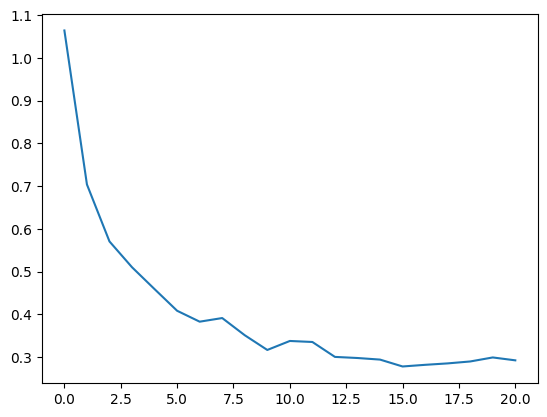

In [4]:

from typing import BinaryIO, List, Optional
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from dataclasses import dataclass
import struct
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class Record:
    """One record from a file ETL9G."""
    jis_code: int
    img: np.ndarray

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


def read_etl9g_records_from_file(f: BinaryIO) -> Optional[Record]:
    """
    Reads one record from a file ETL9G.
    Returns: (jis_code, img)
    """
    s = f.read(8199)
    if not s:
        return None
    r = struct.unpack('>HH8sIBBBBHHHHBB34s8128s7x', s)
    jis_code = r[1]
    img_bytes = r[15]
    
    arr = np.frombuffer(img_bytes, dtype = np.uint8)
    high = arr >> 4
    low = arr & 0x0F
    pixels = np.empty(arr.size * 2, dtype = np.uint8)
    pixels[0::2] = high
    pixels[1::2] = low
    img = pixels.reshape(127, 128)

    return Record(jis_code, img)


def read_etl9g_all_records() -> List[Record]:
    """
    Reads multiple files ETL9G binary
    """
    records = []
    for file in files:
        with open(file, "rb") as f:
            while True:
                record = read_etl9g_records_from_file(f)
                if record == None:
                    break
                if record.jis_code in selected_jis:
                    img = record.img
                    
                    processed_img = preprocess(img)
                    processed_record = Record(record.jis_code, processed_img)
                    records.append(processed_record)

    return records


def preprocess(img: np.ndarray) -> np.ndarray:
    """
    Simple preprocessing steps.
    """
    img = clean_image_background(img)
    img = cut_center_and_scale(img)
    img = convert_to_binary_image(img)
    img = swap_white_and_black(img)
    return img


def create_cnn(with_augmentation=True):
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(127, 128, 1)))

    if with_augmentation:
        model.add(tf.keras.Sequential([
            layers.RandomRotation(0.1),
            layers.RandomZoom(height_factor=(-0.1, 0.0), width_factor=(-0.1, 0.0)),
            # layers.RandomTranslation(0.1, 0.1),   # not needed because images are centered
            # layers.RandomFlip("horizontal")       # shouldn't be used for writing
        ]))

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(selected_jis), activation='softmax'))

    # model.add(layers.Conv2D(32, 3, activation='relu', padding='same'))
    # model.add(layers.MaxPooling2D())

    # model.add(layers.Conv2D(64, 3, activation='relu', padding='same'))
    # model.add(layers.MaxPooling2D())

    # model.add(layers.Conv2D(128, 3, activation='relu', padding='same'))
    # model.add(layers.MaxPooling2D())

    # model.add(layers.GlobalAveragePooling2D())
    # model.add(layers.Dense(256, activation='relu'))
    # model.add(layers.Dropout(0.5))
    # model.add(layers.Dense(len(selected_jis), activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def split_data(records: List[Record]) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Splits the data into training and testing sets.
    """
    images = np.array([record.img for record in records])
    labels = np.array([selected_jis.index(record.jis_code) for record in records])

    images = images[..., np.newaxis]  # add channel dimension

    images_train, images_test, labels_train, labels_test = train_test_split(
        images, labels, test_size=0.2, random_state=42, stratify=labels
    )

    return images_train, images_test, labels_train, labels_test


def save_model(model: tf.keras.Model, path: str):
    """
    Saves the model to the specified path.
    """
    model.export(path)
    converter = tf.lite.TFLiteConverter.from_saved_model(path)
    tflite_model = converter.convert()
    with open(f"{path}.tflite", "wb") as f:
        f.write(tflite_model)


if __name__ == "__main__":
    records = read_etl9g_all_records()
    images_train, images_test, labels_train, labels_test = split_data(records)

    model = create_cnn(with_augmentation=True)

    history = model.fit(
        images_train, labels_train,
        validation_data=(images_test, labels_test),
        epochs=50,
        shuffle=True,
        callbacks=[early_stop]
    )
    plt.plot(history.history['val_loss'])

    model_no_augmentation = create_cnn(with_augmentation=False)
    model_no_augmentation.set_weights(model.get_weights())
    save_model(model_no_augmentation, f"{OUTPUT_PATH}/cnn_etl9g_{len(selected_jis)}s_50e_nomargin_smooth_simplev2")



Testing if all pictures are fine after cleaning background

Central pixels count: 451 Mean brightness: 5.150776053215077


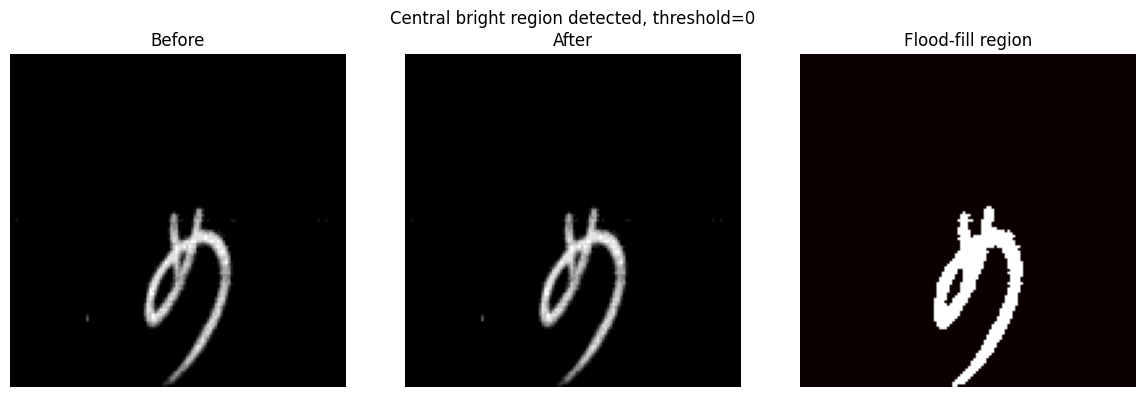

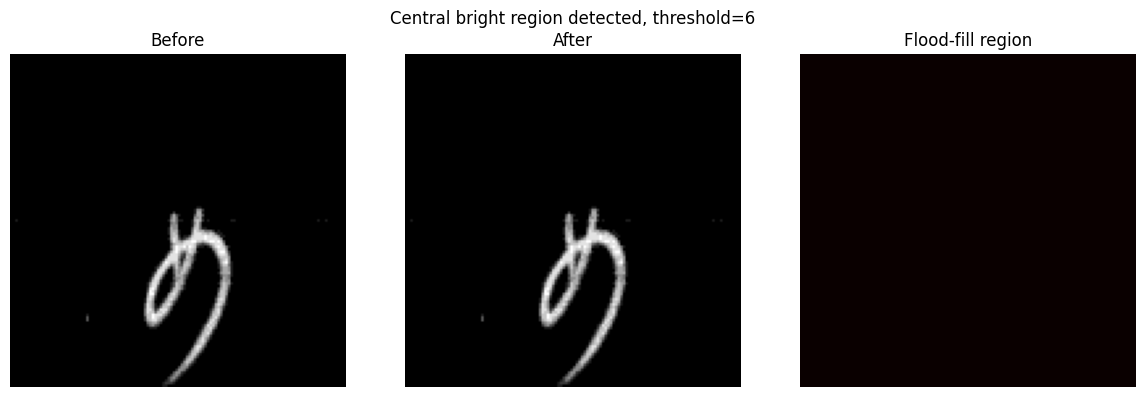

Central pixels count: 451 Mean brightness: 5.150776053215077


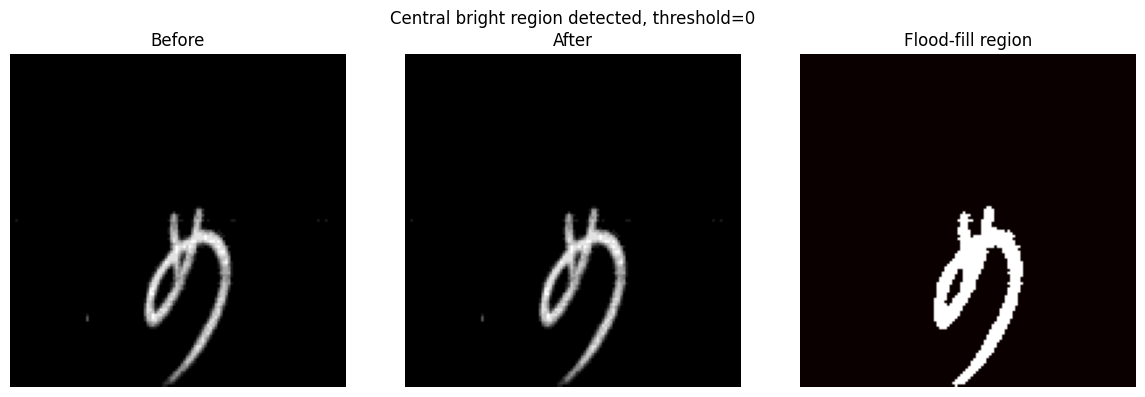

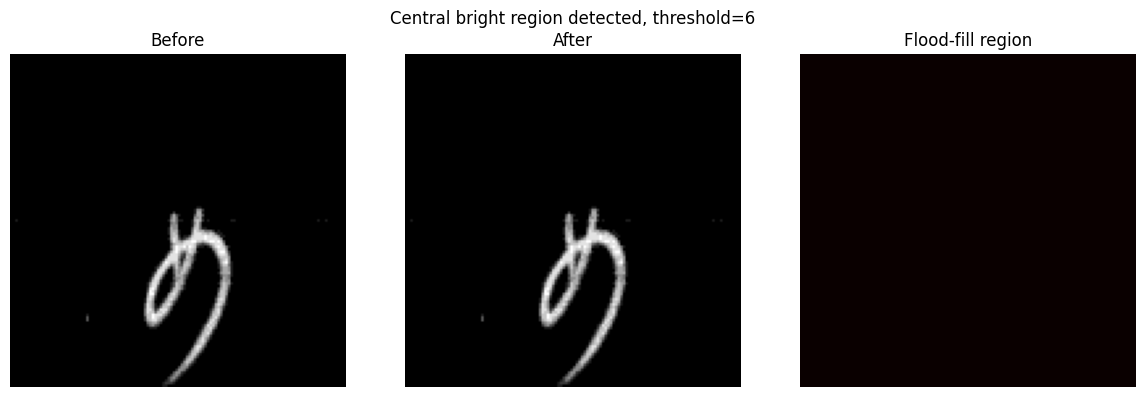

In [5]:

from typing import BinaryIO, List, Optional
from matplotlib.pylab import sqrt
from tensorflow.keras.callbacks import EarlyStopping
from dataclasses import dataclass
import struct
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class Record:
    """One record from a file ETL9G."""
    jis_code: int
    img: np.ndarray

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

def _show_debug(before, after, pixels, title="Debug"):
    mask = np.zeros_like(before)
    for x, y in pixels:
        mask[x, y] = 255

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(before, cmap='gray')
    axes[0].set_title("Before")

    axes[1].imshow(after, cmap='gray')
    axes[1].set_title("After")

    axes[2].imshow(mask, cmap='hot')
    axes[2].set_title("Flood-fill region")

    for ax in axes:
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def clean_image_background(
    img: np.ndarray,
    debug: bool = True
) -> np.ndarray:

    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)
    before = img.copy()

    def is_central_bright_region(pixels):
        if len(pixels) < 50:
            return False

        xs = np.array([p[0] for p in pixels])
        ys = np.array([p[1] for p in pixels])

        # odległość każdego piksela od środka
        dists = np.sqrt((xs - h/2)**2 + (ys - w/2)**2)

        # normalizacja
        norm_dists = dists / np.sqrt((h/2)**2 + (w/2)**2)

        # maska pikseli blisko środka
        central_mask = norm_dists < 0.3
        if not np.any(central_mask):
            return False

        # średnia jasność tylko pikseli blisko środka
        mean_brightness = before[xs[central_mask], ys[central_mask]].mean()
        
        if debug:
            print("Central pixels count:", central_mask.sum(), "Mean brightness:", mean_brightness)

        # warunek: jest blisko środka i średnia jasność > 7
        return mean_brightness > 4



    def flood_fill(start_x: int, start_y: int, threshold: int):
        removed_pixels = []
        queue = [(start_x, start_y)]

        while queue:
            x, y = queue.pop()
            if visited[x, y]:
                continue
            visited[x, y] = True

            if img[x, y] > threshold:
                removed_pixels.append((x, y))
                img[x, y] = 0
                for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                        queue.append((nx, ny))

        return removed_pixels

    def repeat_flood_fill(x, y):
        threshold = 0
        while threshold < 15:
            pixels = flood_fill(x, y, threshold)

            if threshold > 0:
                _show_debug(before, img, pixels, title=f"Central bright region detected, threshold={threshold}")

            if not is_central_bright_region(pixels):
                # OK, flood-fill usunął tylko bezpieczne piksele
                break

            # cofamy flood-fill
            for px, py in pixels:
                img[px, py] = before[px, py]
                visited[px, py] = False

            if debug:
                _show_debug(before, img, pixels, title=f"Central bright region detected, threshold={threshold}")

            threshold += 6

    # ==== FLOOD FILLS FROM BORDERS ====
    for i in range(h):
        for y in [0, w-1]:
            repeat_flood_fill(i, y)

    for i in range(w):
        for x in [0, h-1]:
            repeat_flood_fill(x, i)

    return img



def read_etl9g_records_from_file(f: BinaryIO) -> Optional[Record]:
    """
    Reads one record from a file ETL9G.
    Returns: (jis_code, img)
    """
    s = f.read(8199)
    if not s:
        return None
    r = struct.unpack('>HH8sIBBBBHHHHBB34s8128s7x', s)
    jis_code = r[1]
    img_bytes = r[15]
    
    arr = np.frombuffer(img_bytes, dtype = np.uint8)
    high = arr >> 4
    low = arr & 0x0F
    pixels = np.empty(arr.size * 2, dtype = np.uint8)
    pixels[0::2] = high
    pixels[1::2] = low
    img = pixels.reshape(127, 128)

    return Record(jis_code, img)


def read_etl9g_all_records() -> List[Record]:
    """
    Reads multiple files ETL9G binary
    """
    records = []
    for file in files:
        with open(file, "rb") as f:
            while True:
                record = read_etl9g_records_from_file(f)
                if record == None:
                    break
                if record.jis_code in selected_jis:
                    img = record.img
                    clean_image_background(img)

records = read_etl9g_all_records()

